#인공지능개론 6주차 과제

###컴퓨터공학과 202337644 김태규
---

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 데이터 로드 및 전처리
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/abalone.csv')
df = df.drop('id', axis=1)

#라벨 인코딩
글자로 된 카테고리 데이터를 숫자로 바꾸는 방법<br><br>
딥러닝 모델은 수학적인 계산을 통해 학습하기 때문에 'M(수컷)', 'F(암컷)' 같은 글자를 직접 이해할 수 없습니다. 그래서 이 글자들을 컴퓨터가 계산할 수 있는 0, 1, 2... 같은 숫자로 변환해주는 과정이 필요하다<br><br>
라벨 인코딩은 데이터를 깔끔하게 숫자로 바꿔주어 메모리를 적게 차지하고 속도가 빠르지만, 모델이 숫자의 크기를 오해하지 않도록 상황에 맞춰 써야 하는 도구

In [12]:
# 라벨 인코딩
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

# X, y 분리
X = df.drop('Rings', axis=1).values
y = df['Rings'].values

# 데이터 분할 및 스케일링
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

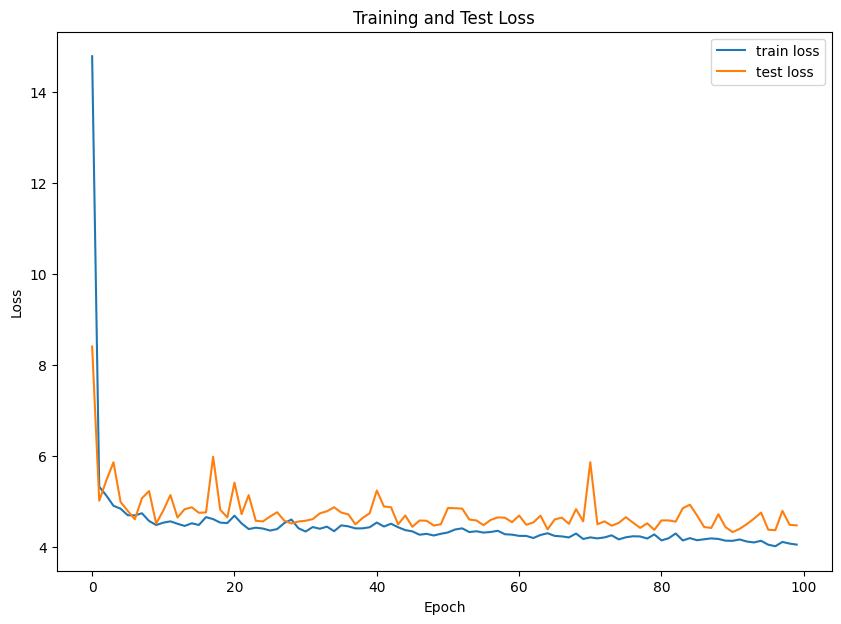

In [8]:
# 모델 설계
model_reg = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

# 컴파일 및 학습
N_EPOCHS = 100
model_reg.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=['mae'])
history = model_reg.fit(X_train, y_train, epochs=N_EPOCHS, batch_size=32, validation_data=(X_test, y_test), verbose=0) # 학습 과정 출력 생략

# loss 체크
plt.figure(figsize=(10,7))
plt.plot(range(N_EPOCHS), history.history['loss'], label='train loss')
plt.plot(range(N_EPOCHS), history.history['val_loss'], label='test loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.show()

In [11]:
# 예측 수행
y_pred = model_reg.predict(X_test).flatten()

# 성능 지표 계산
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("\n" + "="*30)
print("   Regression Result Summary")
print("="*30)
print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print("-" * 30)

# 실제값과 예측값 샘플 비교 (10개)
result_df = pd.DataFrame({'Actual': y_test, 'Predicted': np.round(y_pred, 1)})
print("\n[ 실제값 vs 예측값 비교 (Sample) ]")
print(result_df.head(10))

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

   Regression Result Summary
Mean Absolute Error (MAE) : 1.5073
Mean Squared Error (MSE)  : 4.4661
Root Mean Squared Error (RMSE): 2.1133
------------------------------

[ 실제값 vs 예측값 비교 (Sample) ]
   Actual  Predicted
0      13       15.8
1       8        9.7
2      11       10.7
3       5        4.7
4      12       10.8
5      11       11.1
6       7        8.5
7       8       10.4
8       7        8.4
9       9       12.4
